In [1]:
%load_ext autotime

import scarf
scarf.__version__

'1.0.0'

time: 1.32 s (started: 2026-06-25 23:23:39 +02:00)


In [2]:
scarf.fetch_dataset(
    dataset_name='kang_15K_pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True
)

scarf.fetch_dataset(
    dataset_name='kang_14K_ifnb-pbmc_rnaseq', 
    save_path='scarf_datasets',
    as_zarr=True
)

time: 29.7 s (started: 2026-06-25 23:23:40 +02:00)


In [3]:
ds_ctrl = scarf.DataStore(
    'scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr/',
    nthreads=4
)

ds_ctrl

DataStore has 8487 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'cluster_labels', 'RNA_percentRibo', 
            'RNA_percentMito', 'RNA_nCounts', 'RNA_leiden_cluster', 'RNA_UMAP2', 'RNA_nFeatures', 
            'RNA_UMAP1'
   RNA assay has 11352 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
            'I__hvgs'

time: 710 ms (started: 2026-06-25 23:24:10 +02:00)


In [4]:
ds_stim = scarf.DataStore(
    'scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr',
    nthreads=4
)

ds_stim

DataStore has 10111 (14446) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_nFeatures', 'RNA_leiden_cluster', 
            'RNA_nCounts', 'cluster_labels', 'RNA_percentRibo', 'RNA_percentMito', 'RNA_UMAP2', 
            'RNA_UMAP1'
   RNA assay has 11051 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'

time: 679 ms (started: 2026-06-25 23:24:10 +02:00)


In [5]:
#Can be used to merge multiple assays
scarf.ZarrMerge(
    # Path where merged Zarr files will be saved
    zarr_path='scarf_datasets/kang_merged_pbmc_rnaseq.zarr',  
    
    # assays to be merged
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    
    # these names will be preprended to the cell ids with '__' delimiter
    names=['ctrl', 'stim'],
    
    # Name of the merged assay. `overwrite` will remove an existing Zarr file.
    merge_assay_name='RNA',
    overwrite=True
).dump()

/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=22, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=16, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. 

/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=15, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)
/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=19, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. 

Writing data from assay 1/2 to merged file:   0%|                                                             …

Writing data from assay 2/2 to merged file:   0%|                                                             …

time: 32 s (started: 2026-06-25 23:24:11 +02:00)


In [6]:
ds = scarf.DataStore(
    'scarf_datasets/kang_merged_pbmc_rnaseq.zarr',
    nthreads=4
)

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

time: 20.7 s (started: 2026-06-25 23:24:43 +02:00)


In [7]:
ds

DataStore has 29065 (29065) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'orig_RNA_UMAP1', 'orig_cluster_labels', 
            'RNA_percentRibo', 'RNA_percentMito', 'orig_RNA_UMAP2', 'orig_RNA_nCounts', 'orig_RNA_percentRibo', 
            'orig_RNA_percentMito', 'orig_RNA_nFeatures', 'orig_RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 
          
   RNA assay has 12450 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

time: 154 ms (started: 2026-06-25 23:25:04 +02:00)


In [8]:
ds.cells.head()

,I,ids,names,orig_RNA_nCounts,orig_cluster_labels,orig_RNA_UMAP2,orig_RNA_percentMito,RNA_percentMito,RNA_percentRibo,RNA_nFeatures,RNA_nCounts,orig_RNA_percentRibo,orig_RNA_leiden_cluster,orig_RNA_nFeatures,orig_RNA_UMAP1
0,True,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,574.0,nan,NaN,0.000000,0.000000,20.034843,304.0,574.0,20.034843,-1,304.0,NaN
1,True,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,1682.0,nan,NaN,0.000000,0.000000,0.059453,62.0,1682.0,0.059453,-1,62.0,NaN
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,1168.0,CD4 Memory T,-5.990341,0.171233,0.171233,31.763699,434.0,1168.0,31.763699,1,434.0,-1.768571
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,2158.0,CD8 T,-12.830768,0.185357,0.185357,32.483781,837.0,2158.0,32.483781,7,837.0,-3.052445
4,True,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,1395.0,B,-5.425503,0.143369,0.143369,34.695341,592.0,1395.0,34.695341,5,592.0,-12.654625


time: 569 ms (started: 2026-06-25 23:25:04 +02:00)


In [9]:
ds.cells.insert(
    column_name='sample_id',
    values=[x.split('__')[0] for x in ds.cells.fetch_all('ids')],
    overwrite=True
)

time: 97.5 ms (started: 2026-06-25 23:25:05 +02:00)


/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=4, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


In [10]:
ctrl_labels = list(ds_ctrl.cells.fetch_all('cluster_labels'))
stim_labels = list(ds_stim.cells.fetch_all('cluster_labels'))

ds.cells.insert(
    column_name='imported_labels',
    values=ctrl_labels + stim_labels,
    overwrite=True
)

time: 119 ms (started: 2026-06-25 23:25:05 +02:00)


/home/parashar/scarf/.venv/lib/python3.14/site-packages/zarr/core/dtype/npy/string.py:249: UnstableSpecificationWarning: The data type (FixedLengthUTF32(length=12, endianness='little')) does not have a Zarr V3 specification. That means that the representation of arrays saved with this data type may change without warning in a future version of Zarr Python. Arrays stored with this data type may be unreadable by other Zarr libraries. Use this data type at your own risk! Check https://github.com/zarr-developers/zarr-extensions/tree/main/data-types for the status of data type specifications for Zarr V3.
  v3_unstable_dtype_warning(self)


In [11]:
ctrl_valid_cells = list(ds_ctrl.cells.fetch_all('I'))
stim_valid_cells = list(ds_stim.cells.fetch_all('I'))

ds.cells.update_key(
    values=ctrl_valid_cells + stim_valid_cells,
    key='I'
)

time: 130 ms (started: 2026-06-25 23:25:05 +02:00)


In [12]:
ds.cells.to_pandas_dataframe(
    ['sample_id'],
    key='I'
)['sample_id'].value_counts()

sample_id
ctrl    9441
stim    9157
Name: count, dtype: int64

time: 131 ms (started: 2026-06-25 23:25:05 +02:00)


INFO: Calculating summary statistics


(RNA) Computing nCells:   0%|                                                                                 …

(RNA) Computing normed_tot:   0%|                                                                             …

(RNA) Computing sigmas:   0%|                                                                                 …

INFO: Calculating HVGs


INFO: 2000 genes marked as HVGs


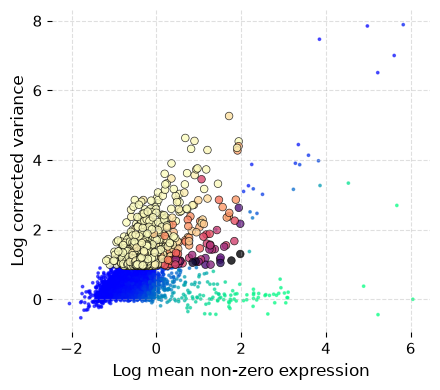

time: 22.3 s (started: 2026-06-25 23:25:05 +02:00)


In [13]:
ds.mark_hvgs(
    min_cells=10,
    top_n=2000,
    min_mean=-3, 
    max_mean=2,
    max_var=6
)

In [14]:
ds.make_graph(
    feat_key='hvgs',
    k=21, 
    dims=25,
    n_centroids=100
)

Writing data to normed__I__hvgs/data:   0%|                                                                   …

Calculating mean of norm. data:   0%|                                                                         …

Calculating std. dev. of norm. data:   0%|                                                                    …

Fitting PCA:   0%|                                                                                            …

Fitting ANN:   0%|                                                                                            …

...

Estimating seed partitions:   0%|                                                                             …

Identifying neighbors:   0%|                                                                                  …

Smoothening KNN distances:   0%|                                                                              …

INFO: ANN recall: 99.91%


time: 1min 16s (started: 2026-06-25 23:25:28 +02:00)


In [15]:
ds.run_umap(
    n_epochs=250, 
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP:   0%|                                                                                          …

	completed  0  /  250 epochs


	completed  25  /  250 epochs


	completed  50  /  250 epochs


	completed  75  /  250 epochs


...

	completed  150  /  250 epochs


	completed  175  /  250 epochs


	completed  200  /  250 epochs


	completed  225  /  250 epochs


time: 15.1 s (started: 2026-06-25 23:26:44 +02:00)


In [16]:
ds.cells.head()

,I,ids,names,orig_RNA_UMAP1,orig_RNA_UMAP2,orig_RNA_percentMito,RNA_nFeatures,RNA_percentMito,orig_RNA_nCounts,RNA_percentRibo,orig_RNA_percentRibo,orig_RNA_nFeatures,orig_cluster_labels,orig_RNA_leiden_cluster,imported_labels,RNA_nCounts,sample_id,RNA_UMAP1,RNA_UMAP2
0,True,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,NaN,NaN,0.000000,304.0,0.000000,574.0,20.034843,20.034843,304.0,nan,-1,CD4 naive T,574.0,ctrl,-15.585618,-12.254915
1,True,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,NaN,NaN,0.000000,62.0,0.000000,1682.0,0.059453,0.059453,62.0,nan,-1,CD 14 Mono,1682.0,ctrl,33.580681,7.697722
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,-1.768571,-5.990341,0.171233,434.0,0.171233,1168.0,31.763699,31.763699,434.0,CD4 Memory T,1,CD 14 Mono,1168.0,ctrl,9.893784,-7.985840
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,-3.052445,-12.830768,0.185357,837.0,0.185357,2158.0,32.483781,32.483781,837.0,CD8 T,7,CD 14 Mono,2158.0,ctrl,-1.828203,-12.354437
4,False,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,-12.654625,-5.425503,0.143369,592.0,0.143369,1395.0,34.695341,34.695341,592.0,B,5,nan,1395.0,ctrl,NaN,NaN


time: 776 ms (started: 2026-06-25 23:26:59 +02:00)


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


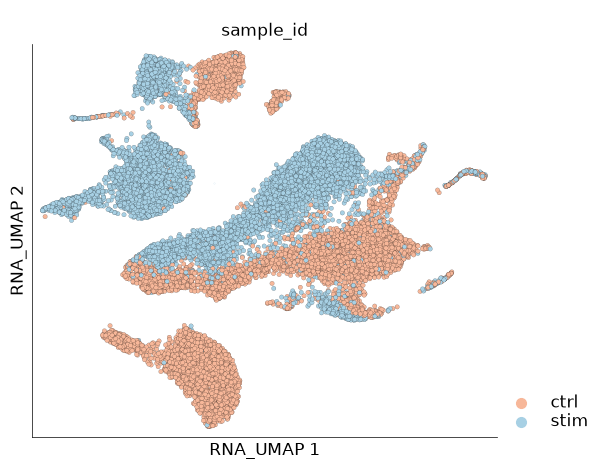

time: 996 ms (started: 2026-06-25 23:27:00 +02:00)


In [17]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='sample_id',
    cmap='RdBu', 
    legend_ondata=False
)

/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


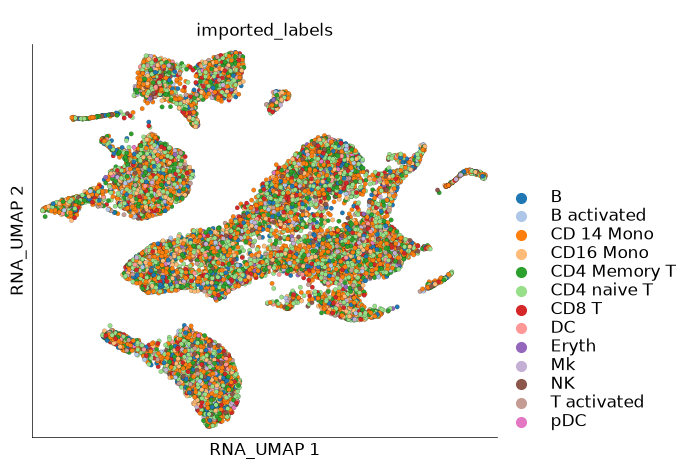

time: 1.23 s (started: 2026-06-25 23:27:01 +02:00)


In [18]:
ds.plot_layout(
    layout_key='RNA_UMAP', 
    color_by='imported_labels',
    legend_ondata=False
)

In [19]:
ds.cells.insert(
    column_name=f'is_ctrl',
    values=(ds.cells.fetch_all('sample_id') == 'ctrl'),
    overwrite=True
)

time: 115 ms (started: 2026-06-25 23:27:02 +02:00)


In [20]:
ds.make_graph(
    feat_key='hvgs',
    k=21, 
    dims=25,
    n_centroids=100,
    pca_cell_key='is_ctrl'
)

INFO: Using existing normalized data with cell key I and feat key I__hvgs


Fitting PCA:   0%|                                                                                            …

Fitting ANN:   0%|                                                                                            …

Fitting kmeans:   0%|                                                                                         …

Estimating seed partitions:   0%|                                                                             …

Identifying neighbors:   0%|                                                                                  …

Smoothening KNN distances:   0%|                                                                              …

INFO: ANN recall: 99.84%


time: 32.3 s (started: 2026-06-25 23:27:02 +02:00)


In [21]:
ds.run_umap(
    n_epochs=250, 
    spread=5,
    min_dist=1,
    parallel=True,
    label='pUMAP'
)

Training UMAP:   0%|                                                                                          …

	completed  0  /  250 epochs


	completed  25  /  250 epochs


	completed  50  /  250 epochs


	completed  75  /  250 epochs


...

	completed  150  /  250 epochs


	completed  175  /  250 epochs


	completed  200  /  250 epochs


	completed  225  /  250 epochs


time: 16.6 s (started: 2026-06-25 23:27:35 +02:00)


/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


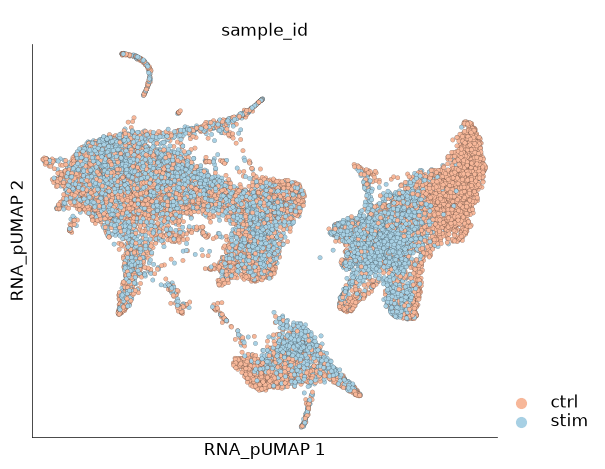

time: 847 ms (started: 2026-06-25 23:27:51 +02:00)


In [22]:
ds.plot_layout(
    layout_key='RNA_pUMAP',
    color_by='sample_id',
    cmap='RdBu',
    legend_ondata=False
)

/home/parashar/scarf/scarf/plots.py:658: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


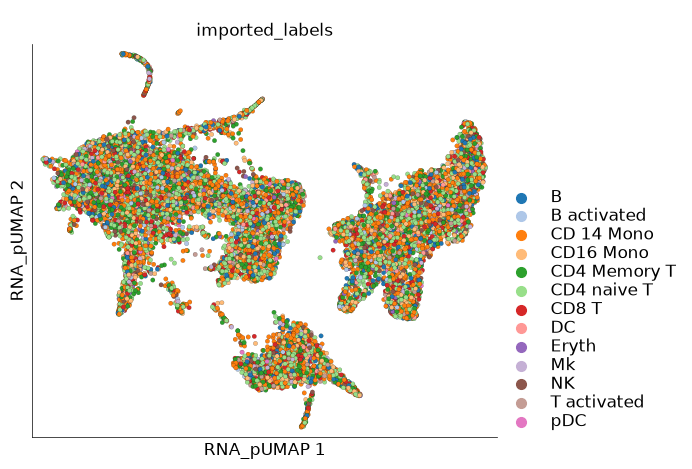

time: 1.28 s (started: 2026-06-25 23:27:52 +02:00)


In [23]:
ds.plot_layout(
    layout_key='RNA_pUMAP',
    color_by='imported_labels',
    legend_ondata=False
)